## Feature Engineering

### Handling missing values


In [108]:
import pandas as pd 
import numpy as np
data = pd.read_csv('titanic.csv')
df = pd.DataFrame(data)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [109]:
print("Count of missing values in a feature of Dataset")
print(df.isnull().sum())

Count of missing values in a feature of Dataset
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


##### Impute missing values with the median(for skewed dataset)


In [110]:

df['Age'] = df['Age'].fillna(df['Age'].median())

In [111]:
#After handling missing values
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


### Handling categorical values

In [112]:
# Replace missing value with most frequent values
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [113]:
df = df.drop('Cabin', axis=1) # Cabin is dropped

In [114]:
print("After handling all missing values")
print(df.isnull().sum())

After handling all missing values
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


### Scale the Features

#### Scaling age and Fare

In [115]:
from sklearn.preprocessing import StandardScaler, RobustScaler

standard_scaler = StandardScaler()
df['Age'] = standard_scaler.fit_transform(df[['Age']])
print("\n Standard scaled age:\n", df['Age'])




 Standard scaled age:
 0     -0.565736
1      0.663861
2     -0.258337
3      0.433312
4      0.433312
         ...   
886   -0.181487
887   -0.796286
888   -0.104637
889   -0.258337
890    0.202762
Name: Age, Length: 891, dtype: float64


In [53]:
robust_scaler = RobustScaler()
df['Fare'] = robust_scaler.fit_transform(df[['Fare']])
print("\n Robust scaled fare:\n", df['Fare'])


 Robust scaled fare:
 0     -0.312011
1      2.461242
2     -0.282777
3      1.673732
4     -0.277363
         ...   
886   -0.062981
887    0.673281
888    0.389604
889    0.673281
890   -0.290356
Name: Fare, Length: 891, dtype: float64


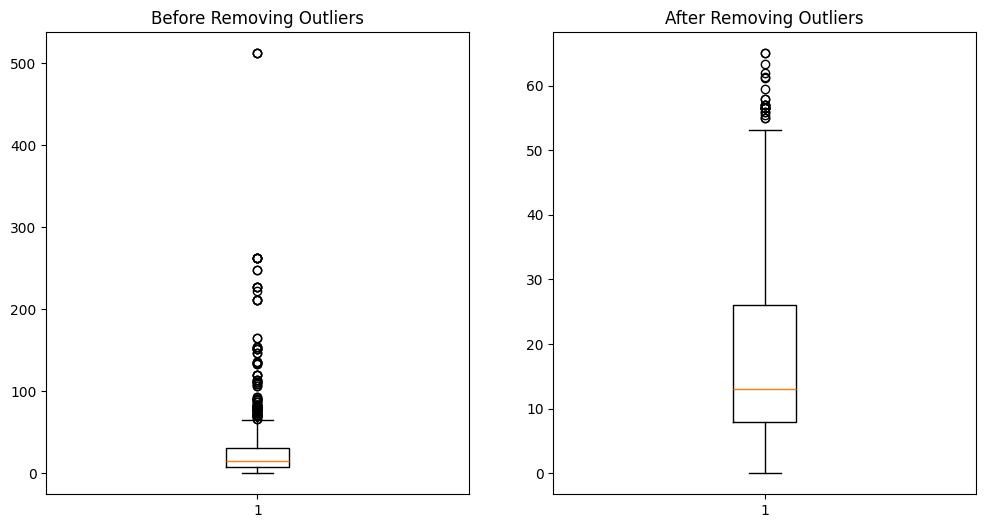

Data after removing outliers:
   PassengerId  Survived  Pclass  \
0            1         0       3   
2            3         1       3   
3            4         1       1   
4            5         0       3   
5            6         0       3   

                                           Name     Sex       Age  SibSp  \
0                       Braund, Mr. Owen Harris    male -0.565736      1   
2                        Heikkinen, Miss. Laina  female -0.258337      0   
3  Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  0.433312      1   
4                      Allen, Mr. William Henry    male  0.433312      0   
5                              Moran, Mr. James    male -0.104637      0   

   Parch            Ticket     Fare Embarked  
0      0         A/5 21171   7.2500        S  
2      0  STON/O2. 3101282   7.9250        S  
3      0            113803  53.1000        S  
4      0            373450   8.0500        S  
5      0            330877   8.4583        Q  


In [116]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Compute Q1 Q3 and IQR
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)
IQR = Q3 - Q1

# calculate lower_bound and upper_bound
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_filtered = df[(df['Fare'] >= lower_bound) & (df['Fare'] <= upper_bound)] # remove outliar

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

ax1.boxplot(df['Fare'])
ax1.set_title("Before Removing Outliers")

ax2.boxplot(df_filtered['Fare'])
ax2.set_title("After Removing Outliers")

plt.show()

print("Data after removing outliers:")
print(df_filtered.head())

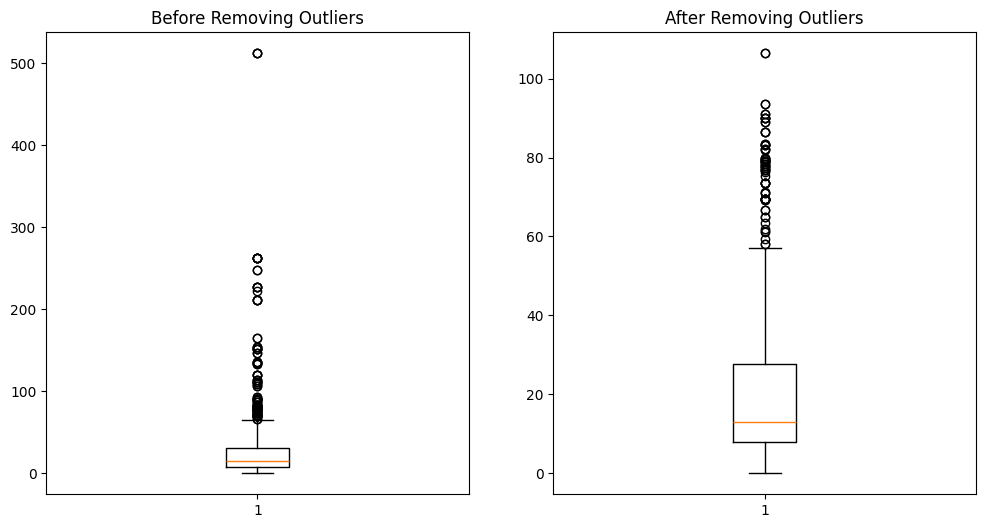

Data after removing outliers (Z-score method):
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex       Age  SibSp  \
0                            Braund, Mr. Owen Harris    male -0.565736      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  0.663861      1   
2                             Heikkinen, Miss. Laina  female -0.258337      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  0.433312      1   
4                           Allen, Mr. William Henry    male  0.433312      0   

   Parch            Ticket     Fare Embarked  
0      0         A/5 21171   7.2500        S  
1      0          PC 17599  71.2833        C  
2      0  STON/O2. 3101282   7.9250        S  
3      0            113803  53.1000        S  
4      0      

In [117]:
from sklearn.preprocessing import StandardScaler

# Reshape data for scaling
data_reshaped = df[['Fare']].values  

# Use StandardScaler to compute Z-scores
scaler = StandardScaler()
z_scores = scaler.fit_transform(data_reshaped)

# Define a threshold (commonly 3)
threshold = 1.5
df_filtered_z = df[np.abs(z_scores) < threshold]

# Plot before and after removing outliers
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

ax1.boxplot(df['Fare'])
ax1.set_title("Before Removing Outliers")

ax2.boxplot(df_filtered_z['Fare'])
ax2.set_title("After Removing Outliers")

plt.show()

print("Data after removing outliers (Z-score method):")
print(df_filtered_z.head())

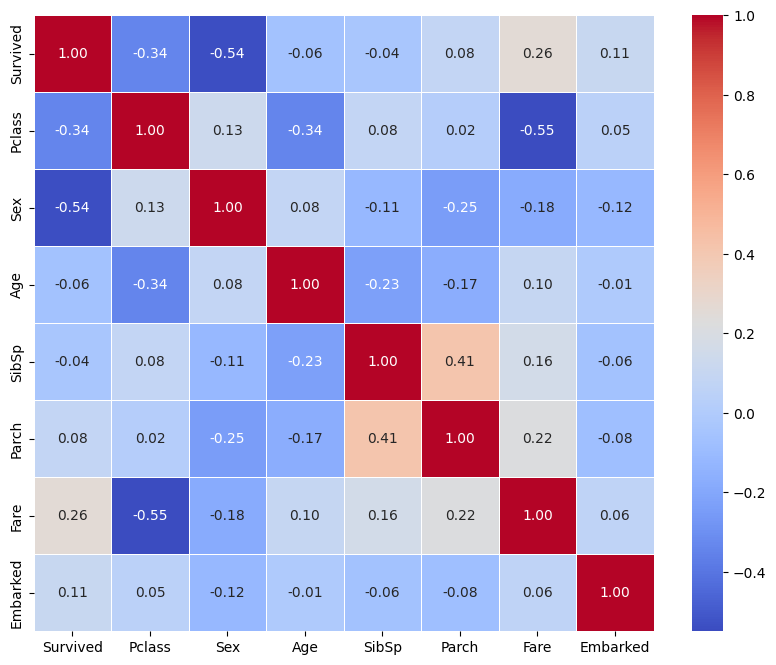

In [118]:
import seaborn as sns
import matplotlib.pyplot as plt

df['Sex'] = df['Sex'].map({'male': 1, 'female': 0})
df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})
df = df.drop(['PassengerId', 'Name', 'Ticket'], axis=1)
# Calculate correlation matrix
corr_matrix = df.corr()

plt.figure(figsize=(10, 8))

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.show()


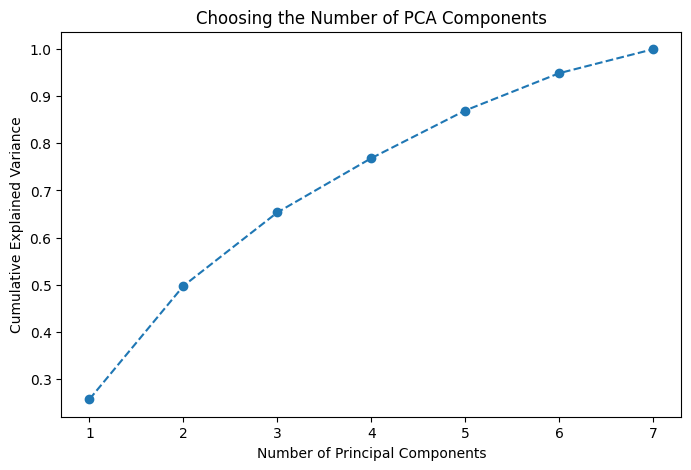

In [122]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Selecting numerical features
numerical_features = df.select_dtypes(include=['float64', 'int64']).drop(columns=['Survived'], errors='ignore')  # Drop target if applicable

# Standardizing the features
scaler = StandardScaler()
scaled_data = scaler.fit_transform(numerical_features)

pca = PCA()
pca.fit(scaled_data)

# Calculate cumulative variance
explained_variance = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker='o', linestyle='--')

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Choosing the Number of PCA Components")
plt.show()

In [124]:
# Find optimal components
optimal_components = np.argmax(explained_variance >= 0.95) + 1
print(f"Optimal number of components: {optimal_components}")
pca_optimal = PCA(n_components=optimal_components)
pca_features = pca_optimal.fit_transform(scaled_data)



Optimal number of components: 7
